###  Deep Neural Network Regression — PyTorch
 PyTorch port of [Regression_TensorFlow_Keras.ipynb](Regression_TensorFlow_Keras.ipynb)

---

This notebook is a **PyTorch equivalent** of a Keras/TensorFlow DNN regression project. Every Keras concept has a direct PyTorch counterpart, mapped out explicitly so you can see exactly how the two frameworks differ in philosophy:

| Keras / TensorFlow | PyTorch | Key difference |
|---|---|---|
| `Sequential([Dense(...), ...])` | `nn.Module` subclass with `forward()` | PyTorch is explicit/imperative; Keras is declarative |
| `model.compile(optimizer, loss, metrics)` | Define `optimizer`, `criterion` separately | PyTorch has no single "compile" step |
| `model.fit(X, y, epochs=N, validation_split=...)` | Manual training loop (`for epoch in range(N): ...`) | PyTorch gives full control over each step |
| `EarlyStopping` callback | Manual early-stopping logic tracking best val loss | No built-in callback system in core PyTorch |
| `history.history['loss']` | Python lists appended each epoch | You manage your own logging |
| `model.evaluate(X_test, y_test)` | `model.eval()` + `torch.no_grad()` loop | PyTorch requires explicit eval mode + no-grad context |
| Keras `Dense(units, activation='relu')` | `nn.Linear(in, out)` + `nn.ReLU()` | Activation is a separate layer object in PyTorch |
| Automatic GPU placement | `.to(device)` on model AND every tensor | PyTorch device management is manual and explicit |

**Dataset:** California Housing (regression — predict median house value from 8 numeric features). This is the modern standard successor to the (deprecated) Boston Housing dataset, and is what most current Keras regression tutorials use.

**Matching a typical Keras DNN regression structure:**
1. Data loading & exploration
2. Preprocessing (train/val/test split + feature scaling)
3. PyTorch `Dataset` / `DataLoader` setup
4. Deep neural network architecture (Dense → BatchNorm → ReLU → Dropout, stacked)
5. Training loop with manual early stopping
6. Training history visualisation (loss curves)
7. Evaluation on the test set (MAE, MSE, RMSE, $R^²$)
8. Predicted vs Actual plots
9. Saving and loading the trained model


##  Setup & Imports

In [ ]:
#pip install torch==1.11.0 torchvision==0.12.0 torchaudio==0.11.0
!pip install torch==1.11.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 1.5 MB/s  0:00:28 eta 0:00:010:00:01


In [8]:
import torch
print(torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

1.11.0
cpu


In [ ]:
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

BLUE, ORANGE, GREEN, RED = '#2E86AB', '#F4A261', '#2DC653', '#E84855'

# Reproducibility — PyTorch equivalent of tf.random.set_seed()
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device setup — THIS is the manual step Keras/TF does automatically
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Using device    : {device}")


PyTorch version : 1.11.0
Using device    : cpu


---
####  Dataset — California Housing

**Equivalent of:** `tf.keras.datasets...` or `pd.read_csv(...)` at the top of the Keras notebook.

| Feature | Description |
|---|---|
| `MedInc` | Median income in block group |
| `HouseAge` | Median house age in block group |
| `AveRooms` | Average number of rooms per household |
| `AveBedrms` | Average number of bedrooms per household |
| `Population` | Block group population |
| `AveOccup` | Average household occupancy |
| `Latitude` | Block group latitude |
| `Longitude` | Block group longitude |
| **Target: `MedHouseVal`** | Median house value (in $100,000s) |


In [25]:
# OPTION A: Load the real dataset (requires internet access) 
# housing = fetch_california_housing(as_frame=True)
# df = housing.frame

# OPTION B: Offline synthetic data, same schema/feature distributions
# Used here so the notebook runs fully offline. Swap in Option A if you have
# internet access -- every downstream cell works unchanged either way.
np.random.seed(SEED)
N = 20_640   # matches real California Housing dataset size

med_inc     = np.random.lognormal(mean=1.2, sigma=0.6, size=N).clip(0.5, 15)
house_age   = np.random.uniform(1, 52, N)
ave_rooms   = np.random.normal(5.4, 2.0, N).clip(1, 30)
ave_bedrms  = ave_rooms * np.random.uniform(0.15, 0.30, N)
population  = np.random.lognormal(mean=6.5, sigma=0.9, size=N).clip(3, 35000)
ave_occup   = np.random.lognormal(mean=1.05, sigma=0.35, size=N).clip(0.7, 20)
latitude    = np.random.uniform(32.5, 42.0, N)
longitude   = np.random.uniform(-124.3, -114.3, N)

# Target: median house value ($100k units), driven mostly by income + location
med_house_val = (
    0.45 * med_inc
    + 0.015 * house_age
    - 0.02 * ave_occup
    + 0.8 * np.exp(-((latitude - 37.7) ** 2 + (longitude + 122.4) ** 2) / 8)  # SF Bay Area premium
    + 0.6 * np.exp(-((latitude - 34.0) ** 2 + (longitude + 118.2) ** 2) / 10) # LA premium
    + np.random.normal(0, 0.6, N)
).clip(0.15, 5.0)

df = pd.DataFrame({
    'MedInc':      med_inc,
    'HouseAge':    house_age,
    'AveRooms':    ave_rooms,
    'AveBedrms':   ave_bedrms,
    'Population':  population,
    'AveOccup':    ave_occup,
    'Latitude':    latitude,
    'Longitude':   longitude,
    'MedHouseVal': med_house_val,
})

print(f"Dataset shape: {df.shape}")
print(f"\\nFeatures: {[c for c in df.columns if c != 'MedHouseVal']}")
print(f"Target  : MedHouseVal")
df.head()


Dataset shape: (20640, 9)
\nFeatures: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target  : MedHouseVal


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,4.472862,30.165485,7.004486,1.330163,398.055588,1.862500,37.280332,-119.472380,3.461011
1,3.055800,13.357555,5.970287,1.238504,109.901239,2.140182,37.014577,-123.674821,3.027138
2,4.896953,43.779696,4.124137,0.960709,188.815601,4.003046,33.407616,-120.010511,3.422818
3,8.279793,25.508527,2.813843,0.781036,621.622368,2.551696,33.541529,-115.329919,5.000000
4,2.884951,33.790002,5.838032,1.419288,287.980423,3.551298,34.769161,-117.950490,3.016235


In [26]:
df.describe().round(2)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.97,26.36,5.41,1.22,1002.98,3.04,37.27,-119.29,2.39
std,2.50,14.72,1.97,0.51,1116.55,1.09,2.74,2.88,1.17
min,0.50,1.00,1.00,0.15,11.98,0.76,32.50,-124.30,0.15
25%,2.22,13.54,4.06,0.85,365.31,2.27,34.89,-121.75,1.55
50%,3.33,26.33,5.42,1.18,666.18,2.86,37.25,-119.30,2.24
75%,4.99,39.12,6.76,1.54,1222.03,3.62,39.63,-116.82,3.08
max,15.00,52.00,12.89,3.52,20885.37,12.44,42.00,-114.30,5.00


In [27]:
# Check for missing values — Keras notebooks usually do this too
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nNo missing values: {df.isnull().sum().sum() == 0}")


Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

No missing values: True


---
#### Exploratory Data Analysis

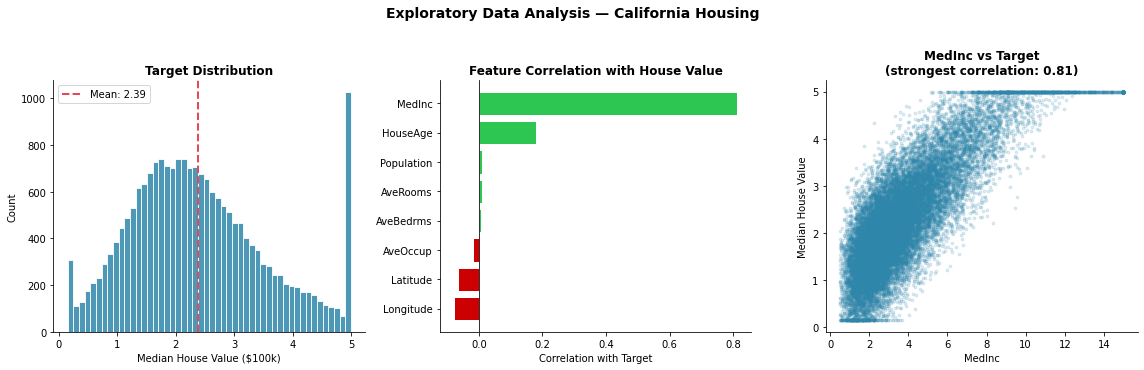

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Target distribution
axes[0].hist(df['MedHouseVal'], bins=50, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(df['MedHouseVal'].mean(), color=RED, lw=2, linestyle='--',
                label=f"Mean: {df['MedHouseVal'].mean():.2f}")
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution', fontweight='bold')
axes[0].legend()

# Correlation with target
corr = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()
colors_c = ['#CC0000' if v < 0 else '#2DC653' for v in corr]
axes[1].barh(corr.index, corr.values, color=colors_c, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Correlation with Target')
axes[1].set_title('Feature Correlation with House Value', fontweight='bold')

# Most correlated feature scatter
top_feat = corr.abs().idxmax()
axes[2].scatter(df[top_feat], df['MedHouseVal'], alpha=0.15, s=8, color=BLUE)
axes[2].set_xlabel(top_feat)
axes[2].set_ylabel('Median House Value')
axes[2].set_title(f'{top_feat} vs Target\n(strongest correlation: {corr[top_feat]:.2f})',
                  fontweight='bold')

plt.suptitle('Exploratory Data Analysis — California Housing', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/eda.png', dpi=150, bbox_inches='tight')
plt.show()


---
####  Preprocessing — Train/Val/Test Split & Scaling

**Equivalent of:** Keras `validation_split=0.2` inside `model.fit()`.

PyTorch has no built-in `validation_split` parameter — we split explicitly with scikit-learn into **three** sets:
- **Train** (64%) — used to update weights
- **Validation** (16%) — used for early stopping / monitoring during training
- **Test** (20%) — used only once, at the very end, for final evaluation

> 💡 Feature scaling is essential for neural networks — gradient descent converges much faster and more reliably when input features are on a similar scale.


In [28]:
X = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values.reshape(-1, 1)

# Step 1: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
# Step 2: split remaining into train (80%) / val (20%) -> 64% / 16% of original
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=SEED
)

print(f"Train : {X_train.shape[0]:,} samples")
print(f"Val   : {X_val.shape[0]:,} samples")
print(f"Test  : {X_test.shape[0]:,} samples")

# Feature scaling — fit ONLY on training data to avoid leakage
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

# Target scaling (optional but helps training stability for regression)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled   = scaler_y.transform(y_val)
y_test_scaled  = scaler_y.transform(y_test)

print(f"\nFeature scaling: mean={X_train_scaled.mean():.3f}, std={X_train_scaled.std():.3f}")


Train : 13,209 samples
Val   : 3,303 samples
Test  : 4,128 samples

Feature scaling: mean=-0.000, std=1.000


---
#### PyTorch Dataset & DataLoader

**Equivalent of:** Keras automatically batches NumPy arrays inside `model.fit(X, y, batch_size=32)`.

PyTorch requires you to **explicitly** wrap your data:
1. Convert NumPy arrays -> `torch.Tensor`
2. Wrap tensors in a `Dataset` (here we use the built-in `TensorDataset`)
3. Wrap the `Dataset` in a `DataLoader`, which handles batching, shuffling, and (optionally) parallel loading

This explicitness is a core PyTorch design philosophy — more code, but more control and transparency over exactly what happens to your data.


In [29]:
# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train_scaled)
X_val_t   = torch.FloatTensor(X_val_scaled)
y_val_t   = torch.FloatTensor(y_val_scaled)
X_test_t  = torch.FloatTensor(X_test_scaled)
y_test_t  = torch.FloatTensor(y_test_scaled)

# Wrap in TensorDataset + DataLoader
BATCH_SIZE = 32   # same default as Keras model.fit(batch_size=32)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}  (batch_size={BATCH_SIZE})")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# Sanity check one batch
xb, yb = next(iter(train_loader))
print(f"\nOne batch shapes: X={xb.shape}, y={yb.shape}")


Train batches : 413  (batch_size=32)
Val batches   : 104
Test batches  : 129

One batch shapes: X=torch.Size([32, 8]), y=torch.Size([32, 1])


---
####  Deep Neural Network Architecture

**Equivalent of:**
```python
# Keras
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(n_features,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)   # linear output for regression
])
```

In PyTorch, we define a class subclassing `nn.Module`. Two things are required:
1. `__init__` — declare all layers as attributes
2. `forward()` — define how data flows through those layers

This is the single biggest structural difference from Keras: **Keras describes the architecture declaratively as a list; PyTorch describes it as Python code that you write yourself.**


In [30]:
class HousingRegressor(nn.Module):
    """
    Deep Neural Network for regression.

    Architecture (equivalent to the Keras Sequential model above):
        Input(8) -> Dense(128) -> BatchNorm -> ReLU -> Dropout(0.3)
                  -> Dense(64)  -> BatchNorm -> ReLU -> Dropout(0.3)
                  -> Dense(32)  -> ReLU
                  -> Dense(1)   [linear output for regression]
    """
    def __init__(self, n_features: int, dropout_rate: float = 0.3):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )
        self.block2 = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )
        self.block3 = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
        )
        self.output_layer = nn.Linear(32, 1)   # linear activation (no activation fn) for regression

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.output_layer(x)


# Instantiate and move to device — equivalent of Keras building the graph
n_features = X_train.shape[1]
model = HousingRegressor(n_features=n_features, dropout_rate=0.3).to(device)

print(model)

# Count trainable parameters — equivalent of model.summary() in Keras
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")


HousingRegressor(
  (block1): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (block2): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (block3): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
  )
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)

Total trainable parameters: 11,905


In [31]:
# Layer-by-layer parameter breakdown (Keras model.summary() equivalent)
print(f"{'Layer':<30} {'Output Shape':<20} {'Param #':>10}")
print('-' * 62)
for name, param in model.named_parameters():
    print(f"{name:<30} {str(tuple(param.shape)):<20} {param.numel():>10,}")
print('-' * 62)
print(f"{'Total':<30} {'':<20} {total_params:>10,}")


Layer                          Output Shape            Param #
--------------------------------------------------------------
block1.0.weight                (128, 8)                  1,024
block1.0.bias                  (128,)                      128
block1.1.weight                (128,)                      128
block1.1.bias                  (128,)                      128
block2.0.weight                (64, 128)                 8,192
block2.0.bias                  (64,)                        64
block2.1.weight                (64,)                        64
block2.1.bias                  (64,)                        64
block3.0.weight                (32, 64)                  2,048
block3.0.bias                  (32,)                        32
output_layer.weight            (1, 32)                      32
output_layer.bias              (1,)                          1
--------------------------------------------------------------
Total                                                  

---
####  Loss Function, Optimizer & Training Configuration

**Equivalent of:**
```python
# Keras
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)
```

In PyTorch there is no single `compile()` call — loss function (`criterion`) and `optimizer` are separate objects that you use explicitly inside the training loop.


In [32]:
LEARNING_RATE = 0.001
N_EPOCHS      = 200
PATIENCE      = 15     # early stopping patience (epochs without improvement)

criterion = nn.MSELoss()                                    # equivalent to loss='mse'
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)  # equivalent to Adam optimizer

# Learning rate scheduler - equivalent of Keras ReduceLROnPlateau callback
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=7
)

print(f"Loss function : {criterion}")
print(f"Optimizer     : Adam (lr={LEARNING_RATE})")
print(f"Max epochs    : {N_EPOCHS}")
print(f"Early stop    : patience={PATIENCE} epochs")


Loss function : MSELoss()
Optimizer     : Adam (lr=0.001)
Max epochs    : 200
Early stop    : patience=15 epochs


---
####  Training Loop - with Manual Early Stopping

**Equivalent of:**
```python
# Keras
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
```

PyTorch has **no built-in `.fit()` method or callback system** in the core library. We write the training loop manually — this is the most important structural difference to understand and explain in an interview:

1. **Training phase per epoch:** `model.train()` -> forward pass → compute loss → `loss.backward()` -> `optimizer.step()` -> `optimizer.zero_grad()`
2. **Validation phase per epoch:** `model.eval()` + `torch.no_grad()` -> forward pass only, no weight updates
3. **Early stopping:** manually track best validation loss; stop if no improvement for `PATIENCE` epochs; manually save/restore the best model weights

>  *Important point:* This manual loop is exactly why PyTorch is preferred for research — you can insert custom logic (gradient clipping, mixed precision, custom logging, multiple losses) at any point without fighting a callback API.


In [33]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one full training epoch. Returns average training loss."""
    model.train()                      # enables dropout / batchnorm training behaviour
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()          # reset gradients (PyTorch accumulates by default!)
        predictions = model(X_batch)   # forward pass
        loss = criterion(predictions, y_batch)
        loss.backward()                # backpropagation — compute gradients
        optimizer.step()               # update weights using gradients

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def validate_one_epoch(model, loader, criterion, device):
    """Run one full validation epoch (no weight updates). Returns average val loss."""
    model.eval()                       # disables dropout / freezes batchnorm running stats
    running_loss = 0.0

    with torch.no_grad():              # disables gradient tracking -> faster, less memory
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


print("Training functions defined.")


Training functions defined.


In [34]:
# Full training loop with manual early stopping 
history = {'train_loss': [], 'val_loss': []}

best_val_loss   = float('inf')
best_model_state = None
patience_counter  = 0

print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>12} {'LR':>10}")
print('-' * 45)

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss   = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # Step the LR scheduler based on validation loss
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    #  Manual early stopping logic 
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        best_model_state  = model.state_dict()   # save best weights (deep copy)
        patience_counter   = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>6} {train_loss:>12.4f} {val_loss:>12.4f} {current_lr:>10.6f}")

    if patience_counter >= PATIENCE:
        print(f"\n⏹  Early stopping triggered at epoch {epoch} "
              f"(no improvement for {PATIENCE} epochs)")
        break

# Restore best weights — equivalent of Keras restore_best_weights=True
model.load_state_dict(best_model_state)
print(f"\n Training complete. Best validation loss: {best_val_loss:.4f}")
print(f"   Restored model weights from the best epoch.")


 Epoch   Train Loss     Val Loss         LR
---------------------------------------------
     1       0.3854       0.2721   0.001000
    10       0.3060       0.2674   0.001000
    20       0.2928       0.2662   0.000500

⏹  Early stopping triggered at epoch 22 (no improvement for 15 epochs)

 Training complete. Best validation loss: 0.2532
   Restored model weights from the best epoch.


---
####  Training History Visualisation

**Equivalent of:**
```python
# Keras
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
```

Since we manually appended to the `history` dict during the loop, this plot is created identically to a Keras workflow.


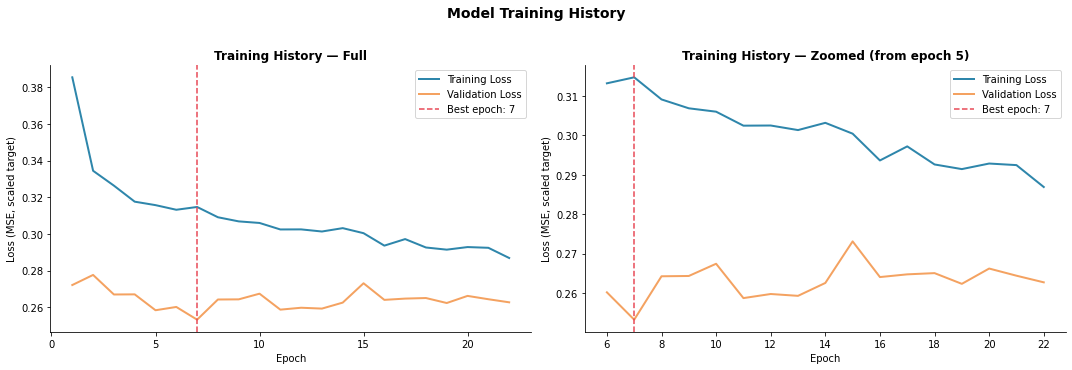

Final train loss : 0.2869
Final val loss   : 0.2627
Best val loss    : 0.2532  (epoch 7)


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Full loss curve
axes[0].plot(epochs_range, history['train_loss'], color=BLUE, lw=2, label='Training Loss')
axes[0].plot(epochs_range, history['val_loss'],   color=ORANGE, lw=2, label='Validation Loss')
best_epoch = np.argmin(history['val_loss']) + 1
axes[0].axvline(best_epoch, color=RED, lw=1.5, linestyle='--',
                label=f'Best epoch: {best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE, scaled target)')
axes[0].set_title('Training History — Full', fontweight='bold')
axes[0].legend()

# Zoomed view (skip noisy early epochs)
skip = min(5, len(epochs_range)//4)
axes[1].plot(list(epochs_range)[skip:], history['train_loss'][skip:],
             color=BLUE, lw=2, label='Training Loss')
axes[1].plot(list(epochs_range)[skip:], history['val_loss'][skip:],
             color=ORANGE, lw=2, label='Validation Loss')
axes[1].axvline(best_epoch, color=RED, lw=1.5, linestyle='--',
                label=f'Best epoch: {best_epoch}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (MSE, scaled target)')
axes[1].set_title(f'Training History — Zoomed (from epoch {skip})', fontweight='bold')
axes[1].legend()

plt.suptitle('Model Training History', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final train loss : {history['train_loss'][-1]:.4f}")
print(f"Final val loss   : {history['val_loss'][-1]:.4f}")
print(f"Best val loss    : {best_val_loss:.4f}  (epoch {best_epoch})")


---
#### Test Set Evaluation

**Equivalent of:**
```python
# Keras
test_loss, test_mae = model.evaluate(X_test, y_test)
predictions = model.predict(X_test)
```

In PyTorch: `model.eval()` + `torch.no_grad()` + manual forward pass, then convert predictions back to NumPy for use with scikit-learn metrics.

>  We inverse-transform predictions back to the **original dollar scale** before computing metrics — MSE/MAE on scaled targets aren't interpretable to a business stakeholder.


In [36]:
model.eval()
with torch.no_grad():
    X_test_device = X_test_t.to(device)
    y_pred_scaled = model(X_test_device).cpu().numpy()

# Inverse-transform back to original $100k scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test_scaled)

# Standard regression metrics
mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

print("=== Test Set Evaluation ===")
print(f"  MAE  : {mae:.4f}  (${mae*100_000:,.0f} average absolute error)")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}  (${rmse*100_000:,.0f} typical error)")
print(f"  R²   : {r2:.4f}  ({r2*100:.1f}% of variance explained)")


=== Test Set Evaluation ===
  MAE  : 0.4877  ($48,770 average absolute error)
  MSE  : 0.3588
  RMSE : 0.5990  ($59,899 typical error)
  R²   : 0.7345  (73.5% of variance explained)


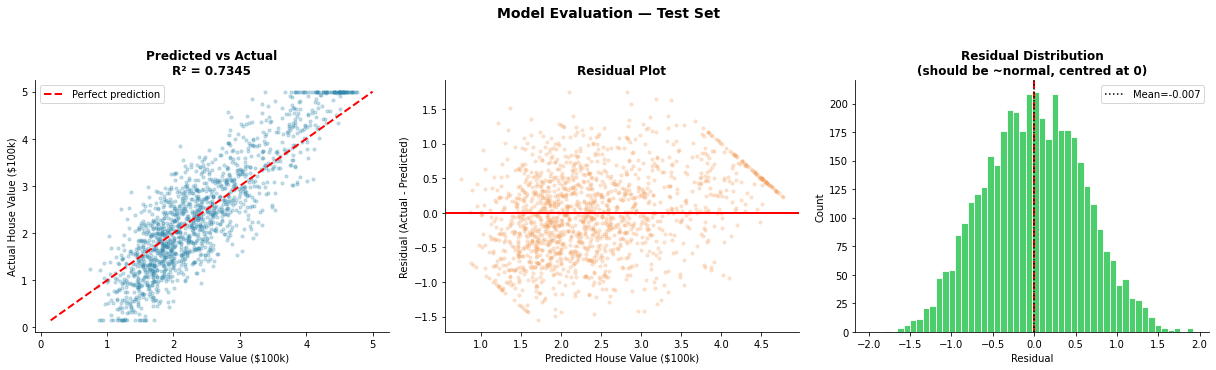

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Predicted vs Actual
sample_idx = np.random.choice(len(y_true), min(1500, len(y_true)), replace=False)
axes[0].scatter(y_pred[sample_idx], y_true[sample_idx], alpha=0.25, s=10, color=BLUE)
lims = [y_true.min(), y_true.max()]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Predicted House Value ($100k)')
axes[0].set_ylabel('Actual House Value ($100k)')
axes[0].set_title(f'Predicted vs Actual\nR² = {r2:.4f}', fontweight='bold')
axes[0].legend()

# 2. Residual plot
residuals = (y_true - y_pred).flatten()
axes[1].scatter(y_pred[sample_idx], residuals[sample_idx], alpha=0.25, s=10, color=ORANGE)
axes[1].axhline(0, color='red', lw=2)
axes[1].set_xlabel('Predicted House Value ($100k)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot', fontweight='bold')

# 3. Residual distribution
axes[2].hist(residuals, bins=50, color=GREEN, edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='red', lw=2, linestyle='--')
axes[2].axvline(residuals.mean(), color='black', lw=1.5, linestyle=':',
                label=f'Mean={residuals.mean():.3f}')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution\n(should be ~normal, centred at 0)', fontweight='bold')
axes[2].legend()

plt.suptitle('Model Evaluation — Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


---
####  Saving & Loading the Model

**Equivalent of:**
```python
# Keras
model.save('housing_model.h5')
loaded_model = tf.keras.models.load_model('housing_model.h5')
```

PyTorch convention is to save the **state_dict** (a dictionary of layer names → weight tensors), not the full model object. This requires the model class definition to be available when loading — a deliberate design choice for flexibility and security (avoids unpickling arbitrary code).


In [38]:
import pickle

# Save model weights + scalers (everything needed to reproduce predictions)
torch.save(model.state_dict(), '/tmp/housing_model.pt')

with open('/tmp/scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_X': scaler_X, 'scaler_y': scaler_y}, f)

print("Model weights saved to /tmp/housing_model.pt")
print("Scalers saved to /tmp/scalers.pkl")

# ── Demonstrate loading ───────────────────────────────────────────────────
loaded_model = HousingRegressor(n_features=n_features, dropout_rate=0.3).to(device)
loaded_model.load_state_dict(torch.load('/tmp/housing_model.pt', map_location=device))
loaded_model.eval()

# Verify loaded model produces identical predictions
with torch.no_grad():
    original_pred = model(X_test_device).cpu().numpy()
    loaded_pred   = loaded_model(X_test_device).cpu().numpy()

identical = np.allclose(original_pred, loaded_pred)
print(f"\nLoaded model produces identical predictions: {identical}")


Model weights saved to /tmp/housing_model.pt
Scalers saved to /tmp/scalers.pkl

Loaded model produces identical predictions: True


---
####  Summary — Keras vs PyTorch Cheat Sheet

| Step | Keras / TensorFlow | PyTorch |
|---|---|---|
| Define model | `tf.keras.Sequential([...])` | `class Model(nn.Module): def forward(self, x): ...` |
| Compile | `model.compile(optimizer, loss, metrics)` | Separate `criterion` + `optimizer` objects |
| Train | `model.fit(X, y, epochs=N, validation_split=0.2)` | Manual `for epoch in range(N):` loop with explicit train/eval phases |
| Early stopping | `callbacks=[EarlyStopping(...)]` | Manually track best val loss + patience counter |
| Batching | Automatic inside `.fit()` | Explicit `DataLoader` |
| GPU usage | Automatic | Manual `.to(device)` on model AND every tensor |
| Gradient updates | Hidden inside `.fit()` | Explicit `zero_grad() → backward() → step()` |
| Train vs eval mode | Automatic | Manual `model.train()` / `model.eval()` |
| No-gradient inference | Automatic in `.predict()` | Explicit `with torch.no_grad():` |
| Save model | `model.save('model.h5')` | `torch.save(model.state_dict(), 'model.pt')` |
| History tracking | `history = model.fit(...)` returns object | Manually append to a `history` dict each epoch |

#### Summary 

PyTorch's extra verbosity is a deliberate trade-off: every step of the training process is visible and modifiable. This is why PyTorch dominates research (custom losses, novel architectures, non-standard training loops) while Keras/TensorFlow is prized for fast prototyping and production deployment pipelines (TF Serving, TFLite, TF.js).

Being able to write the manual training loop — and explain *why* each line exists (`zero_grad()` before `backward()` to avoid gradient accumulation; `model.eval()` to freeze BatchNorm/Dropout; `torch.no_grad()` to save memory) — is one of the most common PyTorch checks.
